# Import Libraries

In [1]:
import numpy             as np
import keras.backend     as K
import matplotlib.pyplot as plt

from sklearn.preprocessing                import LabelEncoder
from sklearn.metrics                      import classification_report, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.initializers        import glorot_uniform
from tensorflow.keras.models              import Model
from tensorflow.keras.layers              import Input,ZeroPadding2D, Dense, Conv2D, Conv3D, DepthwiseConv2D, SeparableConv2D, Conv3DTranspose
from tensorflow.keras.layers              import Flatten, MaxPool2D, AvgPool2D, GlobalAvgPool2D, UpSampling2D, BatchNormalization
from tensorflow.keras.layers              import Concatenate, Add, Dropout, ReLU, Lambda, Activation, LeakyReLU, PReLU
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models              import Model, load_model
from tensorflow.keras                     import layers
from IPython.display                      import SVG
from tensorflow.keras.utils               import model_to_dot
from time                                 import time
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.utils               import plot_model

In [2]:
from tensorflow.keras.preprocessing.image import img_to_array
import os

from tensorflow.keras.callbacks import Callback

import pandas as pd

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dense, Dropout, GlobalAveragePooling2D, SeparableConv2D

# Resume of variables

In [4]:
# Save Directory
save_folder = r'C:\Users\LAPECI\Documents'

num_classes_dataset=21

# Model Name
model_name = 'HS_128D2_Test5'

# train Directory
train_dir = r'C:\Users\LAPECI\Downloads\Plant\train'
valid_dir = r'C:\Users\LAPECI\Downloads\Plant\valid'




# Name saved files after training
savefig_F1Score=f"{model_name}_F1Score_Over_Epochs"
savefig_Precision=f"{model_name}_Precision_Over_Epochs"
savefig_Recall=f"{model_name}_Recall_Over_Epochs"
save_csv_metrics_f1score_precision_recall=f"{model_name}_metrics_history_f1_precision_recall.csv"

H5model_name=f"{model_name}_H5_Model.h5"

savefig_accuracy=f"{model_name}_Accuracy_Over_Epochs"
savefig_loss=f"{model_name}_Loss_Over_Epochs"



save_csv_accuracy_history=f"{model_name}_accuracy_history.csv"
save_csv_loss_history=f"{model_name}_loss_history.csv"
savefig_c_matrix_onH5=f"{model_name}_confusion_matrix"

save_csv_report_onH5=f"{model_name}_classification_report_128x128_OnH5.txt"

save_csv_yval_ypredict_onH5=f"{model_name}_Y_val_Y_predict.csv"


# Define the save path and filename
tflite_filename = f"{model_name}_TFLite.tflite"

savefig_c_matrix_OnTFlite=f"{model_name}_confusion_matrix_On_TFLite"
save_csv_report_OnTFLite=f"{model_name}_classification_report_128x128_OnTFlite.txt"
save_csv_yval_ypredict_OnTFLite=f"{model_name}_Y_val_Y_predict_TFLite.csv"

# SE Block Definition

In [5]:
def se_block(input_tensor, ratio=8):
    channel_axis = -1
    filters = input_tensor.shape[channel_axis]

    se = GlobalAveragePooling2D()(input_tensor)
    se = Dense(filters // ratio, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1, 1, filters))(se)

    return Multiply()([input_tensor, se])

# HardSwish Definition

In [6]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class HardSwish(Layer):
    def call(self, x):
        return x * tf.nn.relu6(x + 3) / 6

In [7]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, PReLU,
    Input, Multiply, Reshape
)

# Proposed Lightweight CNN : ProposedLightweightCNNHS128 - D2

In [8]:
input_shape = (128, 128, 3)

def ProposedLightweightCNNHS128D1(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    
    # Input
    x = Conv2D(16, (3, 3), strides=(2, 2), padding='same')(inputs) 
    x = HardSwish()(x)
    x = BatchNormalization()(x)
    
    # Bloc 1 
    x = SeparableConv2D(32, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = HardSwish()(x)
    
    x = Conv2D(32, (1, 1))(x) 
    x = se_block(x)
    x = MaxPooling2D(pool_size=(2, 2))(x) 
    
    # Bloc 2 
    x = SeparableConv2D(64, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = HardSwish()(x)
    x = Conv2D(64, (1, 1))(x) 
    x = se_block(x)
    x = MaxPooling2D(pool_size=(2, 2))(x) 
    
    
    x = SeparableConv2D(128, (3, 3), padding='same')(x)
    x = HardSwish()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x) 

    # Classification
    x = GlobalAveragePooling2D()(x)
    x = Dense(64)(x) 
    x = HardSwish()(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs=inputs, outputs=output)

model = ProposedLightweightCNNHS128D1(input_shape, num_classes_dataset)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

In [9]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 64, 64, 16)   448         ['input_1[0][0]']                
                                                                                                  
 hard_swish (HardSwish)         (None, 64, 64, 16)   0           ['conv2d[0][0]']                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 64, 64, 16)  64          ['hard_swish[0][0]']         

Total params: 29,105
Trainable params: 28,881
Non-trainable params: 224
__________________________________________________________________________________________________


In [10]:

img_height, img_width = 128, 128 
batch_size = 32



train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=(128, 128),
    batch_size=32,
    label_mode='categorical'
)


def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(normalize).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(normalize).cache().prefetch(buffer_size=AUTOTUNE)

Found 10236 files belonging to 21 classes.
Found 2550 files belonging to 21 classes.


In [11]:
class MetricsCallback(Callback):
    def __init__(self, validation_dataset):
        super(MetricsCallback, self).__init__()
        self.validation_dataset = validation_dataset
        self.f1_scores = []
        self.precisions = []
        self.recalls = []

        
        print("[INFO] Extraction des labels de validation pour le Callback...")
        y_true = []
        for _, labels in validation_dataset:
            y_true.extend(np.argmax(labels.numpy(), axis=1))
        self.y_true_classes = np.array(y_true)

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.validation_dataset, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)

        
        precision = precision_score(self.y_true_classes, y_pred_classes, average='weighted', zero_division=0)
        recall = recall_score(self.y_true_classes, y_pred_classes, average='weighted', zero_division=0)
        f1 = f1_score(self.y_true_classes, y_pred_classes, average='weighted', zero_division=0)

        
        self.precisions.append(precision)
        self.recalls.append(recall)
        self.f1_scores.append(f1)

        
        print(f" — val_precision: {precision:.4f} — val_recall: {recall:.4f} — val_f1: {f1:.4f}")

In [12]:
metrics_callback = MetricsCallback(val_ds)

[INFO] Extraction des labels de validation pour le Callback...


# Start Training the model

In [13]:
import time
from datetime import datetime


start_time = datetime.now()
print("Début de l'entraînement à :", start_time.strftime("%H:%M:%S"))



history = model.fit(train_ds, validation_data=val_ds, epochs=100, verbose=1,callbacks=[metrics_callback])



end_time = datetime.now()
print("Fin de l'entraînement à :", end_time.strftime("%H:%M:%S"))


duration = end_time - start_time
print("Durée de l'entraînement :", str(duration))

Début de l'entraînement à : 06:17:05
Epoch 1/100
320/320 [==============================] - 16s 21ms/step - loss: 2.8920 - accuracy: 0.1038 - val_loss: 3.0129 - val_accuracy: 0.0573
Epoch 2/100
320/320 [==============================] - 6s 20ms/step - loss: 2.2508 - accuracy: 0.2518 - val_loss: 2.2213 - val_accuracy: 0.2659
Epoch 3/100
320/320 [==============================] - 6s 20ms/step - loss: 1.8335 - accuracy: 0.3904 - val_loss: 1.4437 - val_accuracy: 0.5404
Epoch 4/100
320/320 [==============================] - 6s 20ms/step - loss: 1.4531 - accuracy: 0.5021 - val_loss: 1.1921 - val_accuracy: 0.6125
Epoch 5/100
320/320 [==============================] - 6s 20ms/step - loss: 1.2214 - accuracy: 0.5811 - val_loss: 0.9011 - val_accuracy: 0.7286
Epoch 6/100
320/320 [==============================] - 6s 20ms/step - loss: 1.0449 - accuracy: 0.6419 - val_loss: 0.8193 - val_accuracy: 0.7710
Epoch 7/100
320/320 [==============================] - 6s 20ms/step - loss: 0.9062 - accuracy: 0.6

Epoch 29/100
320/320 [==============================] - 6s 20ms/step - loss: 0.1942 - accuracy: 0.9379 - val_loss: 0.1189 - val_accuracy: 0.9604
Epoch 30/100
320/320 [==============================] - 6s 20ms/step - loss: 0.1907 - accuracy: 0.9358 - val_loss: 0.1210 - val_accuracy: 0.9561
Epoch 31/100
320/320 [==============================] - 6s 20ms/step - loss: 0.1879 - accuracy: 0.9404 - val_loss: 0.1085 - val_accuracy: 0.9639
Epoch 32/100
320/320 [==============================] - 6s 20ms/step - loss: 0.1849 - accuracy: 0.9373 - val_loss: 0.1177 - val_accuracy: 0.9557
Epoch 33/100
320/320 [==============================] - 6s 20ms/step - loss: 0.1705 - accuracy: 0.9411 - val_loss: 0.0976 - val_accuracy: 0.9639
Epoch 34/100
320/320 [==============================] - 6s 20ms/step - loss: 0.1703 - accuracy: 0.9454 - val_loss: 0.1032 - val_accuracy: 0.9639
Epoch 35/100
320/320 [==============================] - 6s 20ms/step - loss: 0.1617 - accuracy: 0.9466 - val_loss: 0.0950 - val_ac

320/320 [==============================] - 7s 20ms/step - loss: 0.0515 - accuracy: 0.9805 - val_loss: 0.0425 - val_accuracy: 0.9792
Epoch 86/100
320/320 [==============================] - 6s 20ms/step - loss: 0.0568 - accuracy: 0.9792 - val_loss: 0.0421 - val_accuracy: 0.9788
Epoch 87/100
320/320 [==============================] - 6s 20ms/step - loss: 0.0510 - accuracy: 0.9819 - val_loss: 0.0743 - val_accuracy: 0.9702
Epoch 88/100
320/320 [==============================] - 6s 20ms/step - loss: 0.0542 - accuracy: 0.9801 - val_loss: 0.0491 - val_accuracy: 0.9753
Epoch 89/100
320/320 [==============================] - 6s 20ms/step - loss: 0.0506 - accuracy: 0.9809 - val_loss: 0.0436 - val_accuracy: 0.9816
Epoch 90/100
320/320 [==============================] - 6s 20ms/step - loss: 0.0478 - accuracy: 0.9818 - val_loss: 0.0504 - val_accuracy: 0.9796
Epoch 91/100
320/320 [==============================] - 6s 20ms/step - loss: 0.0502 - accuracy: 0.9795 - val_loss: 0.0511 - val_accuracy: 0.975

# Plot Metrics

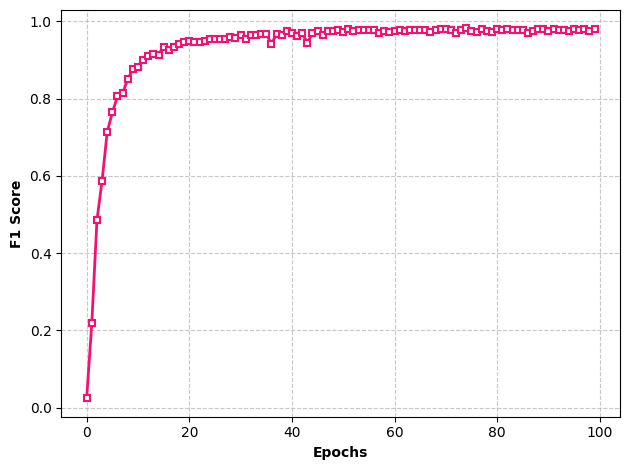

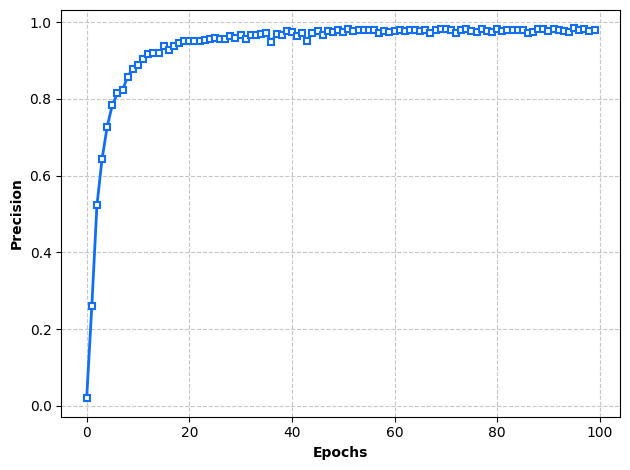

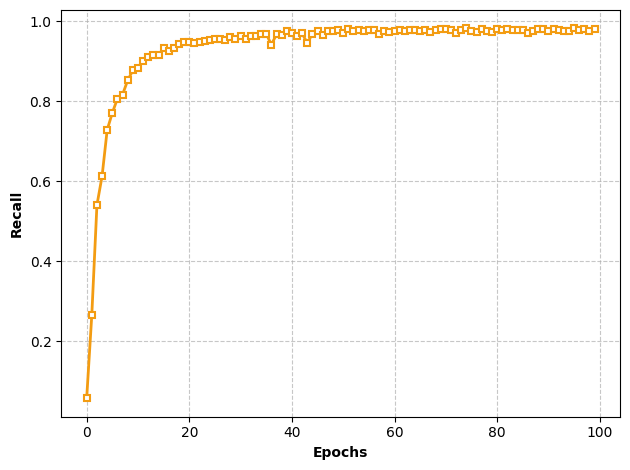

In [14]:

f1_scores = metrics_callback.f1_scores
precisions = metrics_callback.precisions
recalls = metrics_callback.recalls


plt.plot(f1_scores, color='#F3126F', linewidth=2, marker='s', markersize=4, markerfacecolor='white',
         markeredgecolor='#F3126F',
         markeredgewidth=1.5, label='F1-score')

plt.xlabel('Epochs', fontsize=10, weight='bold')
plt.ylabel('F1 Score', fontsize=10, weight='bold')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig(savefig_F1Score, dpi=300, bbox_inches='tight')
plt.show()


plt.plot(precisions, color='#126FF3', linewidth=2, marker='s', markersize=4, markerfacecolor='white',
         markeredgecolor='#126FF3',
         markeredgewidth=1.5,label='Precision')
plt.xlabel('Epochs', fontsize=10, weight='bold')
plt.ylabel('Precision', fontsize=10, weight='bold')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig(savefig_Precision, dpi=300, bbox_inches='tight')
plt.show()

plt.plot(recalls,color='#F39C12', linewidth=2, marker='s', markersize=4, markerfacecolor='white',
         markeredgecolor='#F39C12',
         markeredgewidth=1.5, label='Recall')
plt.xlabel('Epochs', fontsize=10, weight='bold')
plt.ylabel('Recall', fontsize=10, weight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(savefig_Recall, dpi=300, bbox_inches='tight')
plt.show()

# Save Metrics

In [15]:
metrics_df = pd.DataFrame({
    'epoch': range(1, len(f1_scores) + 1),  
    'f1_score': f1_scores,                  
    'precision': precisions,                
    'recall': recalls                       
})

metrics_df.to_csv(save_csv_metrics_f1score_precision_recall, index=False)

# Save Model H5

In [16]:
model.save(H5model_name)

# Model Validation

In [17]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf


model = tf.keras.models.load_model(H5model_name,custom_objects={'HardSwish': HardSwish})


print("[INFO] Extraction des labels réels...")
Y_val = []
for _, labels in val_ds:
    Y_val.extend(np.argmax(labels.numpy(), axis=1))
Y_val = np.array(Y_val)

print("[INFO] Calcul des prédictions sur val_ds...")
y_predict = model.predict(val_ds)
Y_predict = np.argmax(y_predict, axis=1)


accuracy  = accuracy_score(Y_val, Y_predict)
precision = precision_score(Y_val, Y_predict, average='weighted')
recall    = recall_score(Y_val, Y_predict, average='weighted')
f1        = f1_score(Y_val, Y_predict, average='weighted')

print("-" * 30)
print(f"Accuracy:  {accuracy:.15f}")
print(f"Precision: {precision:.15f}")
print(f"Recall:    {recall:.15f}")
print(f"F1 Score:  {f1:.15f}")

[INFO] Extraction des labels réels...
[INFO] Calcul des prédictions sur val_ds...
80/80 [==============================] - 1s 6ms/step
------------------------------
Accuracy:  0.980000000000000
Precision: 0.980384498032347
Recall:    0.980000000000000
F1 Score:  0.979909868690236


# Plot Accuracy over Epochs

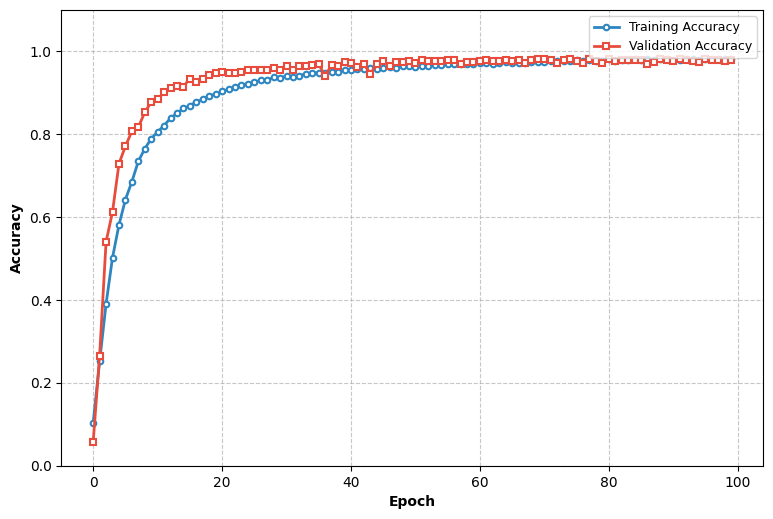

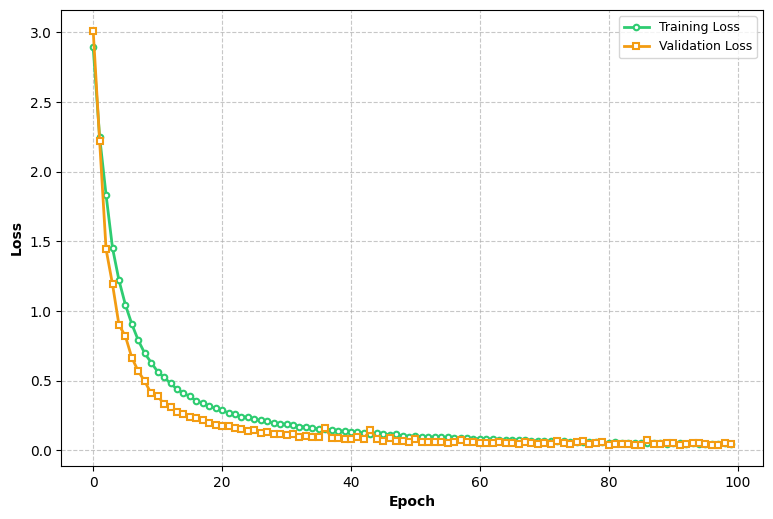

In [18]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(history.history["accuracy"], 
         color='#2E86C1',
         linewidth=2, 
         marker='o',
         markersize=4,
         markerfacecolor='white',
         markeredgecolor='#2E86C1',
         markeredgewidth=1.5,
         label="Training Accuracy")
plt.plot(history.history["val_accuracy"], 
         color='#E74C3C',
         linewidth=2, 
         marker='s',
         markersize=4,
         markerfacecolor='white',
         markeredgecolor='#E74C3C',
         markeredgewidth=1.5,
         label="Validation Accuracy")

plt.xlabel("Epoch", fontsize=10, weight='bold')
plt.ylabel("Accuracy", fontsize=10, weight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=9)
plt.ylim(0, 1.1)

plt.tight_layout()

plt.savefig(savefig_accuracy, dpi=300, bbox_inches='tight')
plt.show()

# Create figure with subplots
plt.figure(figsize=(15, 10))
# Plot loss curves
plt.subplot(2, 2, 1)
plt.plot(history.history["loss"], 
         color='#2ECC71',
         linewidth=2, 
         marker='o',
         markersize=4,
         markerfacecolor='white',
         markeredgecolor='#2ECC71',
         markeredgewidth=1.5,
         label="Training Loss")
plt.plot(history.history["val_loss"], 
         color='#F39C12',
         linewidth=2, 
         marker='s',
         markersize=4,
         markerfacecolor='white',
         markeredgecolor='#F39C12',
         markeredgewidth=1.5,
         label="Validation Loss")

plt.xlabel("Epoch", fontsize=10, weight='bold')
plt.ylabel("Loss", fontsize=10, weight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=9)

plt.tight_layout()

plt.savefig(savefig_loss, dpi=300, bbox_inches='tight')
plt.show()

# Save Accuracy

In [19]:
accuracy_data = pd.DataFrame({
    'epoch': range(1, len(history.history['accuracy']) + 1),  
    'training_accuracy': history.history['accuracy'],         
    'validation_accuracy': history.history['val_accuracy']    
})

accuracy_data.to_csv(save_csv_accuracy_history, index=False)

# Save Loss

In [20]:
loss_data = pd.DataFrame({
    'epoch': range(1, len(history.history['loss']) + 1),  
    'training_loss': history.history['loss'],         
    'validation_loss': history.history['val_loss']    
})

loss_data.to_csv(save_csv_loss_history, index=False)

# Plot Confusion Matrix on H5

In [21]:
import os
New_Plant_Disease_DatasetClasses = sorted(os.listdir(train_dir))

Confusion Matrix


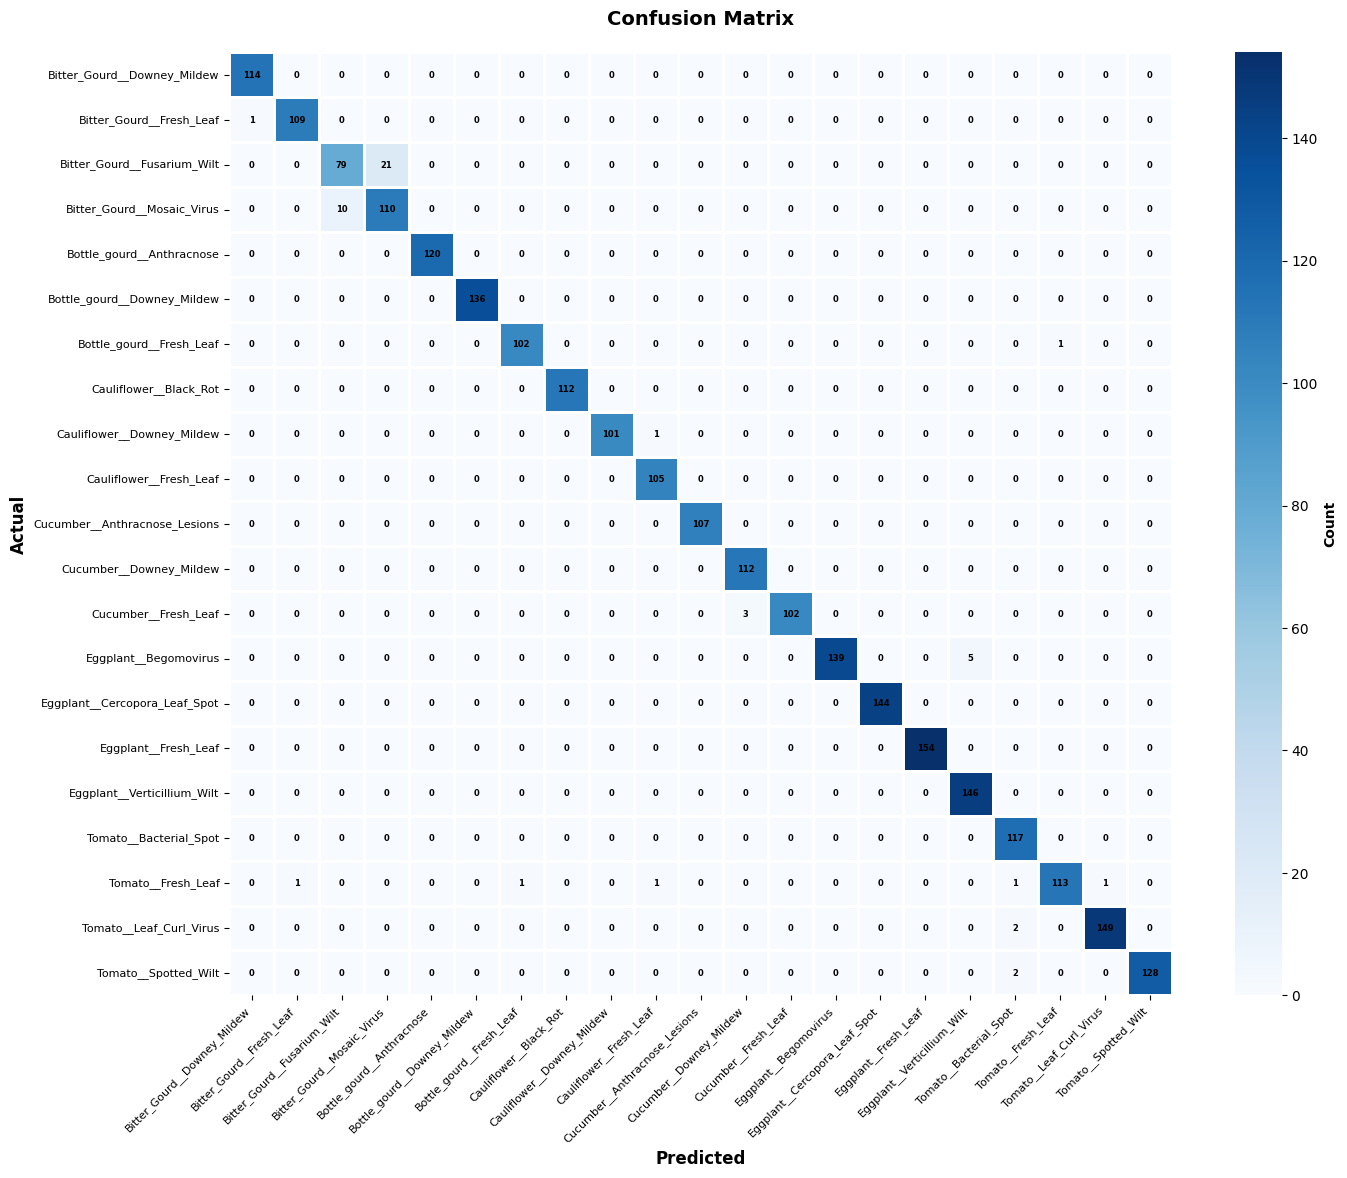

In [22]:
cm = confusion_matrix(Y_val, Y_predict)
print("Confusion Matrix")

plt.figure(figsize=(15, 12))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=New_Plant_Disease_DatasetClasses,
            yticklabels=New_Plant_Disease_DatasetClasses,
            cmap='Blues',
            square=True,
            annot_kws={'size': 6, 'weight': 'bold', 'color': 'black'}, 
            cbar_kws={'label': 'Count'},
            linewidths=1.0,  
            linecolor='white',
            vmin=0, 
            vmax=np.max(cm))  

plt.ylabel('Actual', fontsize=12, weight='bold')
plt.xlabel('Predicted', fontsize=12, weight='bold')
plt.title('Confusion Matrix', fontsize=14, pad=20, weight='bold')

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.gcf().axes[-1].tick_params(labelsize=10)  
plt.gcf().axes[-1].set_ylabel('Count', fontsize=10, weight='bold')

plt.tight_layout(pad=1.5)

plt.savefig(savefig_c_matrix_onH5, dpi=300, bbox_inches='tight')
plt.show()

# Save and show classification report on H5

In [23]:
print("\n[INFO] Rapport de Classification détaillé :")
report = classification_report(Y_val, 
                               Y_predict, 
                               target_names=New_Plant_Disease_DatasetClasses, 
                               digits=4)

print(report)

with open(save_csv_report_onH5, "w") as f:
    f.write(report)


[INFO] Rapport de Classification détaillé :
                               precision    recall  f1-score   support

  Bitter_Gourd__Downey_Mildew     0.9913    1.0000    0.9956       114
     Bitter_Gourd__Fresh_Leaf     0.9909    0.9909    0.9909       110
  Bitter_Gourd__Fusarium_Wilt     0.8876    0.7900    0.8360       100
   Bitter_Gourd__Mosaic_Virus     0.8397    0.9167    0.8765       120
    Bottle_gourd__Anthracnose     1.0000    1.0000    1.0000       120
  Bottle_gourd__Downey_Mildew     1.0000    1.0000    1.0000       136
     Bottle_gourd__Fresh_Leaf     0.9903    0.9903    0.9903       103
       Cauliflower__Black_Rot     1.0000    1.0000    1.0000       112
   Cauliflower__Downey_Mildew     1.0000    0.9902    0.9951       102
      Cauliflower__Fresh_Leaf     0.9813    1.0000    0.9906       105
Cucumber__Anthracnose_Lesions     1.0000    1.0000    1.0000       107
      Cucumber__Downey_Mildew     0.9739    1.0000    0.9868       112
         Cucumber__Fresh_Leaf  

# Save Y_Val et Y_Predict on H5

In [24]:
results_df = pd.DataFrame({
    'Y_val': Y_val,          
    'Y_predict': Y_predict   
})

results_df.to_csv(save_csv_yval_ypredict_onH5, index=False)

# Conversion Tensorflowlite

In [25]:
model = tf.keras.models.load_model(H5model_name,custom_objects={'HardSwish': HardSwish})

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

full_save_path = os.path.join(save_folder, tflite_filename)

with open(full_save_path, 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\LAPECI\AppData\Local\Temp\tmpaxfythga\assets


INFO:tensorflow:Assets written to: C:\Users\LAPECI\AppData\Local\Temp\tmpaxfythga\assets


# Validation Tensorflowlite

In [26]:
interpreter = tf.lite.Interpreter(os.path.join(save_folder,tflite_filename))

In [27]:
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

tflite_predictions = []
all_y_true = []
inference_times = []

print("[INFO] Lancement de l'inférence TFLite sur le dataset de validation...")

for images, labels in val_ds:
    # On stocke les vrais labels
    all_y_true.extend(np.argmax(labels.numpy(), axis=1))
    
    # Pour chaque image dans le batch
    for i in range(images.shape[0]):
        single_img = np.expand_dims(images[i], axis=0) # Ajoute la dimension batch (1, 128, 128, 3)
        
        start = time.time()
        # Configurer le tenseur d'entrée
        interpreter.set_tensor(input_details[0]['index'], single_img)
        # Lancer l'inférence
        interpreter.invoke()
        # Récupérer le résultat
        output_data = interpreter.get_tensor(output_details[0]['index'])
        end = time.time()
        
        inference_times.append(end - start)
        tflite_predictions.append(np.argmax(output_data))

# 4. Conversion en tableaux NumPy
Y_val_tflite = np.array(all_y_true)
Y_pred_tflite = np.array(tflite_predictions)

# 5. Calcul des métriques
accuracy  = accuracy_score(Y_val_tflite, Y_pred_tflite)
precision = precision_score(Y_val_tflite, Y_pred_tflite, average='weighted')
recall    = recall_score(Y_val_tflite, Y_pred_tflite, average='weighted')
f1        = f1_score(Y_val_tflite, Y_pred_tflite, average='weighted')
avg_time  = np.mean(inference_times)

print("-" * 30)
print(f"Résultats TFLite (128x128):")
print(f"Accuracy:  {accuracy:.15f}")
print(f"Precision: {precision:.15f}")
print(f"Recall:    {recall:.15f}")
print(f"F1 Score:  {f1:.15f}")
print(f"Temps d'inférence moyen: {avg_time:.4f} s ({1/avg_time:.2f} FPS)")

[INFO] Lancement de l'inférence TFLite sur le dataset de validation...
------------------------------
Résultats TFLite (128x128):
Accuracy:  0.980000000000000
Precision: 0.980384498032347
Recall:    0.980000000000000
F1 Score:  0.979909868690236
Temps d'inférence moyen: 0.0033 s (306.89 FPS)


# Plot Confusion Matrix on Tensorflowlite

Confusion Matrix On TFLite


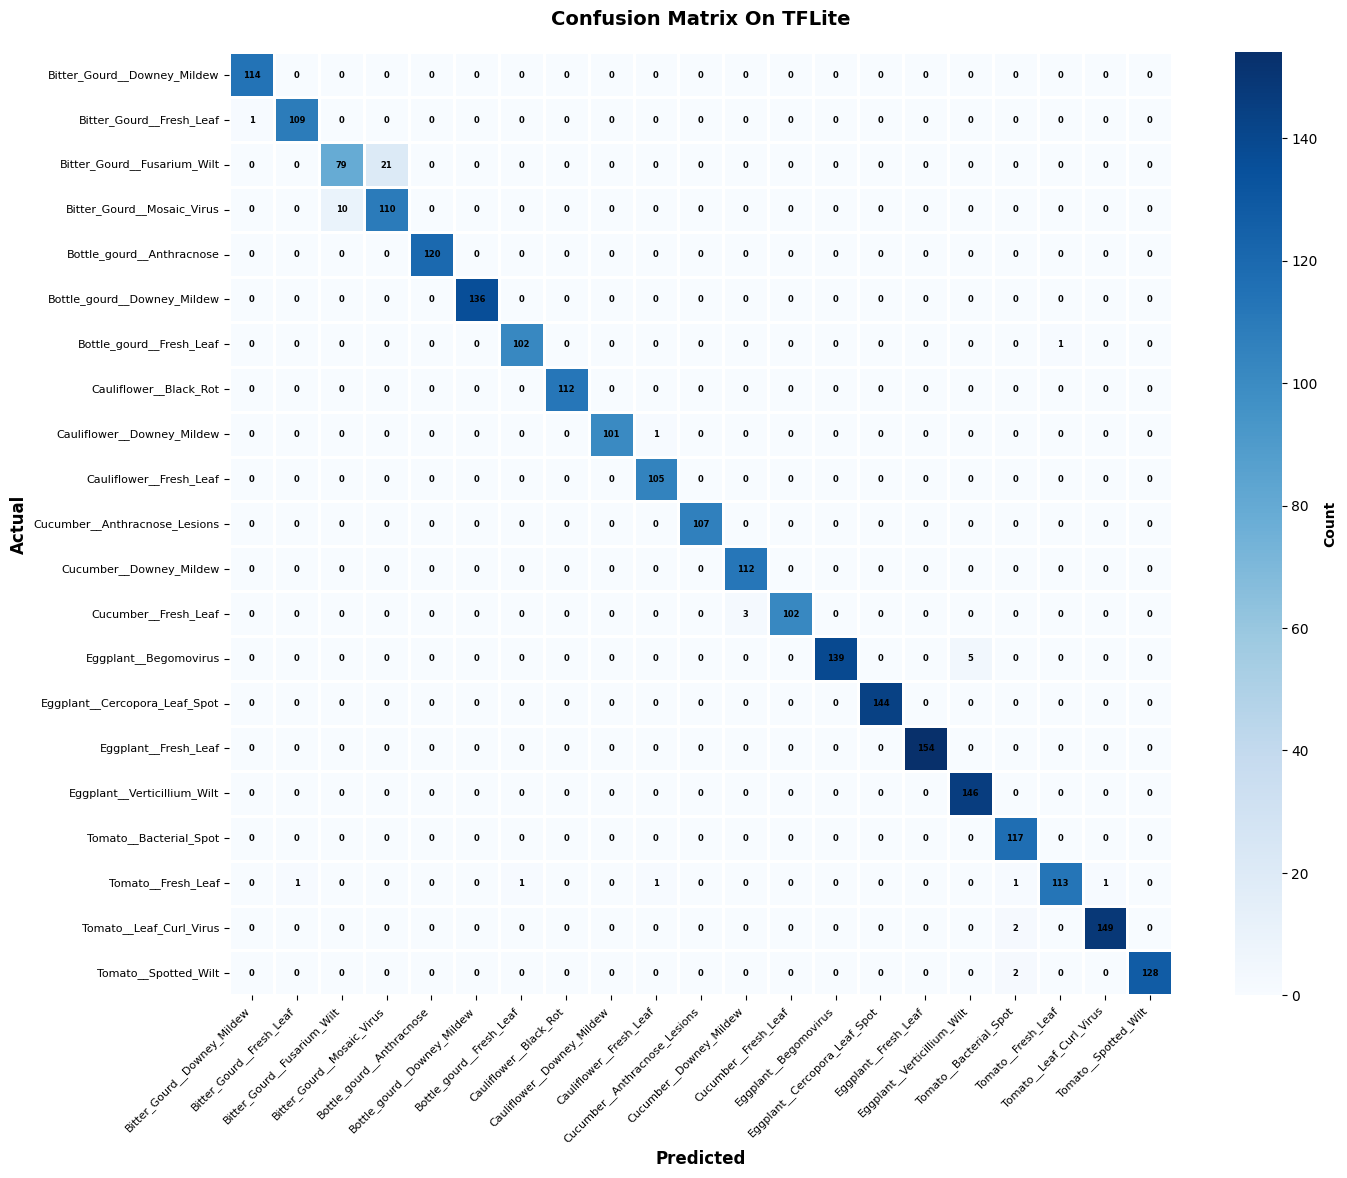

In [28]:
cm = confusion_matrix(Y_val_tflite, Y_pred_tflite)
print("Confusion Matrix On TFLite")

plt.figure(figsize=(15, 12))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=New_Plant_Disease_DatasetClasses,
            yticklabels=New_Plant_Disease_DatasetClasses,
            cmap='Blues',
            square=True,
            annot_kws={'size': 6, 'weight': 'bold', 'color': 'black'},  
            cbar_kws={'label': 'Count'},
            linewidths=1.0,  
            linecolor='white',
            vmin=0,  
            vmax=np.max(cm))  

plt.ylabel('Actual', fontsize=12, weight='bold')
plt.xlabel('Predicted', fontsize=12, weight='bold')
plt.title('Confusion Matrix On TFLite', fontsize=14, pad=20, weight='bold')

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.gcf().axes[-1].tick_params(labelsize=10)  
plt.gcf().axes[-1].set_ylabel('Count', fontsize=10, weight='bold') 

plt.tight_layout(pad=1.5)

plt.savefig(savefig_c_matrix_OnTFlite, dpi=300, bbox_inches='tight')
plt.show()

# Save and Show Classification report on TensorflowLite

In [29]:
print("\n[INFO] Rapport de Classification détaillé :")
report = classification_report(Y_val_tflite, 
                               Y_pred_tflite, 
                               target_names=New_Plant_Disease_DatasetClasses, 
                               digits=4)

print(report)

with open(save_csv_report_OnTFLite, "w") as f:
    f.write(report)


[INFO] Rapport de Classification détaillé :
                               precision    recall  f1-score   support

  Bitter_Gourd__Downey_Mildew     0.9913    1.0000    0.9956       114
     Bitter_Gourd__Fresh_Leaf     0.9909    0.9909    0.9909       110
  Bitter_Gourd__Fusarium_Wilt     0.8876    0.7900    0.8360       100
   Bitter_Gourd__Mosaic_Virus     0.8397    0.9167    0.8765       120
    Bottle_gourd__Anthracnose     1.0000    1.0000    1.0000       120
  Bottle_gourd__Downey_Mildew     1.0000    1.0000    1.0000       136
     Bottle_gourd__Fresh_Leaf     0.9903    0.9903    0.9903       103
       Cauliflower__Black_Rot     1.0000    1.0000    1.0000       112
   Cauliflower__Downey_Mildew     1.0000    0.9902    0.9951       102
      Cauliflower__Fresh_Leaf     0.9813    1.0000    0.9906       105
Cucumber__Anthracnose_Lesions     1.0000    1.0000    1.0000       107
      Cucumber__Downey_Mildew     0.9739    1.0000    0.9868       112
         Cucumber__Fresh_Leaf  

# Save Y_val_tflite et Y_pred_tflite  on TensorflowLite

In [30]:
results_df = pd.DataFrame({
    'Y_val': Y_val_tflite,         
    'Y_predict': Y_pred_tflite   
})

results_df.to_csv(save_csv_yval_ypredict_OnTFLite, index=False)

# FLOPs

In [31]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

model_path = H5model_name
model = tf.keras.models.load_model(model_path,custom_objects={'HardSwish': HardSwish})

full_model = tf.function(lambda x: model(x))
full_model = full_model.get_concrete_function(
    tf.TensorSpec([1] + list(model.input_shape[1:]), model.inputs[0].dtype)
)

frozen_func = convert_variables_to_constants_v2(full_model)
graph_def = frozen_func.graph.as_graph_def()

with tf.Graph().as_default() as graph:
    tf.import_graph_def(graph_def, name='')
    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    
    flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd='op', options=opts)

if flops is not None:
    print(f"\n" + "="*30)
    print(f"MODÈLE : {model_path}")
    print(f"FLOPs totaux : {flops.total_float_ops:,}")
    print(f"GigaFLOPs    : {flops.total_float_ops / 1e9:.4f} GFLOPs")
    print("="*30)

Instructions for updating:
Use `tf.compat.v1.graph_util.tensor_shape_from_node_def_name`


Instructions for updating:
Use `tf.compat.v1.graph_util.tensor_shape_from_node_def_name`



MODÈLE : HS_128D2_Test5_H5_Model.h5
FLOPs totaux : 36,697,642
GigaFLOPs    : 0.0367 GFLOPs
